# Zadanie 1: optymalizacja gradientowa

Termin realizacji: 16 marca 2026

Wybierz jedną z testowych funkcji o dwóch zmiennych do optymalizacji (z [https://en.wikipedia.org/wiki/Test_functions_for_optimization](Test_functions_for_optimization)) (oprócz "sphere function", "Matyas function" i "Booth function").

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Weź implementację optymalizacji gradientowej z zadania z ostatnich ćwiczeń. Zwróć uwagę na:
   1. Punkt powinien być reprezentowany jako tablica (np. `Vector`), a nie jako pojedyncze zmienne.
   2. Funkcja optymalizowana powinna być funkcją, która przyjmuje wektor i zwraca liczbę rzeczywistą.
   3. Gradient powinien być wektorem o tym samym wymierze co punkt.
2. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
3. Przeprowadź procedurę dla kilku kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

Możesz skorzystać z kodu pod zadaniem na 5.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień stały krok z poprzedniego zadania na warunek wystarczającego spadku Armijo. Jako początkowy bracket przyjmij $[0, 1]$. Porównaj zbieżność metody o stałym kroku z przeszukiwaniem liniowym za pomocą wykresów wartości w konkretnym kroku uśrednione między poszczególnymi punktami początkowymi. Porównaj wyniki dla 6 różnych kombinacji parametrów metody Armijo.

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Zamień stały bracket $[0, 1]$ z poprzedniego punktu na metodę automatycznie określającą bracket (przykład z wykładu). Porównaj wyniki z poprzednią metodą dla minimum 6 zestawów parametrów bracketingu.


# ROZWIAZANIE
# 3.0

In [12]:
using LinearAlgebra
using Plots
using Random
using ForwardDiff

# contourf(x, y, z, fill=true, color=:plasma)

In [13]:

function rand_uniform(a, b)
    return rand() * (b-a) + a
end


rand_uniform (generic function with 1 method)

In [14]:
function levi_n13(x::AbstractVector)::Real
    return sin(3π*x[1])^2 + (x[1]-1)^2 * (1 + sin(3π*x[2])^2) + (x[2]-1)^2 * (1 + sin(2π*x[2])^2)
end

function grad_levi_n13(x::AbstractVector)::Vector{Float64}
    return ForwardDiff.gradient(levi_n13, x)
end

levi_domain = [-4.5, 4.5]

function three_hump_camel(x::AbstractVector)::Real
    return 2*x[1]^2 - 1.05*x[1]^4 + x[1]^6/6 + x[1]*x[2] + x[2]^2
end

function grad_three_hump_camel(x::AbstractVector)::Vector{Float64}
    return ForwardDiff.gradient(three_hump_camel, x)    
end

three_hump_domain = [-5.0, 5.0]

2-element Vector{Float64}:
 -5.0
  5.0

In [15]:
function gradient_descent(f, x0::AbstractVector, α::Float64, n_steps::Int, g=nothing)
    x = copy(x0)
    history = Float64[]
    
    if g === nothing
        g = x -> ForwardDiff.gradient(f, x)
    end
    
    for i in 1:n_steps
        push!(history, f(x))
        grad = g(x)
        x = x - α * grad
    end
    
    push!(history, f(x))
    return history, x
end

gradient_descent (generic function with 2 methods)

In [16]:
function run_optimization_experiments(f, domain, n_points::Int, α::Float64, n_steps::Int;)
    plots_array = []
    
    for i in 1:n_points
        x0 = [rand_uniform(domain[1], domain[2]), rand_uniform(domain[1], domain[2])]
        
        try
            history, x_final = gradient_descent(f, x0, α, n_steps)
            
            p = plot(0:n_steps, history, 
                     xlabel="Iteration", 
                     ylabel="f(x)", 
                     title="Start: [$(round(x0[1], digits=2)), $(round(x0[2], digits=2))]",
                     label="α=$α",
                     linewidth=2)
            push!(plots_array, p)
        catch e
            println("Skipped point $i due to error: $e")
        end
    end
    
    plot(plots_array..., layout=(n_points÷2 + n_points%2, 2), size=(1000, 300*n_points÷2))
end

run_optimization_experiments (generic function with 1 method)

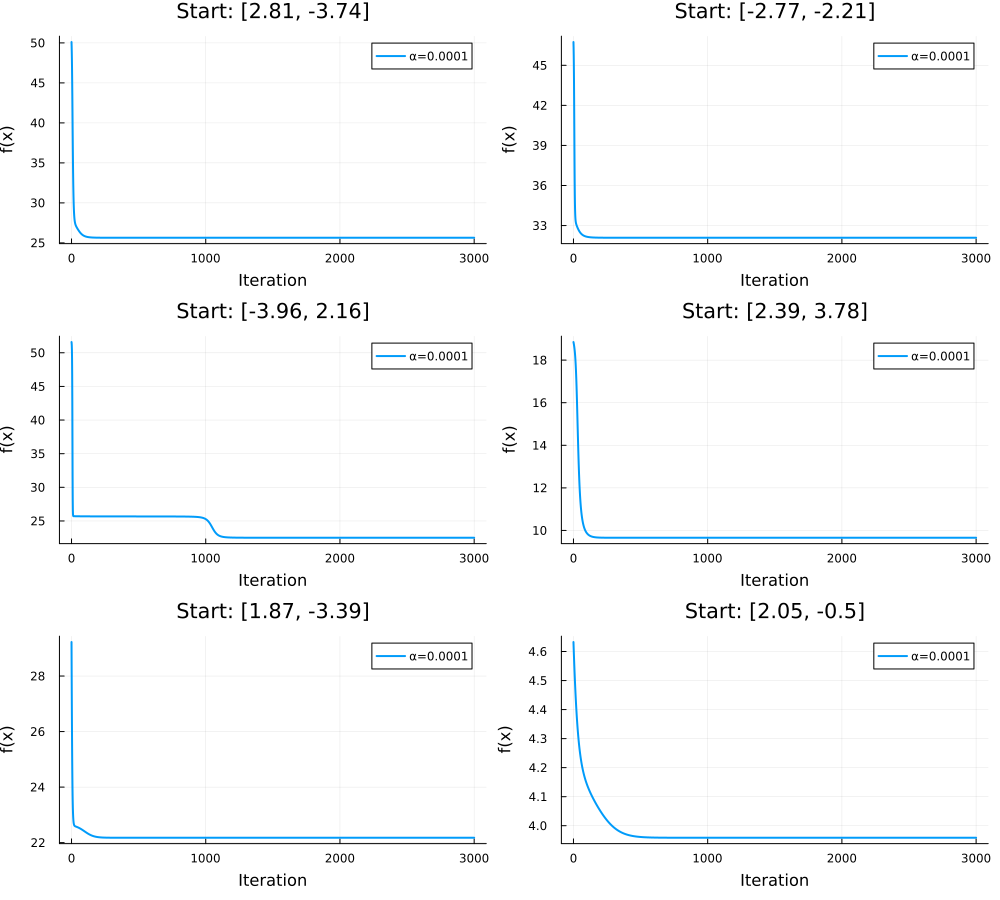

In [17]:
run_optimization_experiments(levi_n13, levi_domain, 6, 0.0001, 3000)

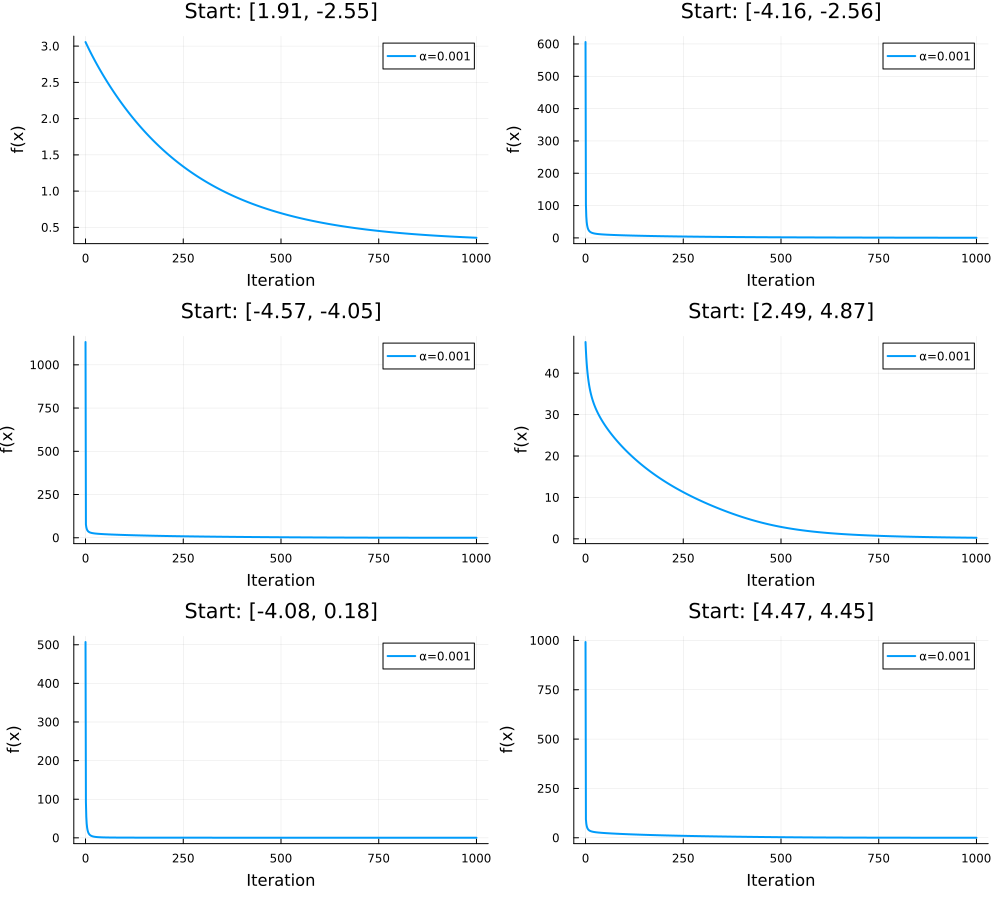

In [18]:

run_optimization_experiments(three_hump_camel, three_hump_domain, 6, 0.001, 1000)

# 4.0

In [19]:
function armijo_line_search(f, x, grad, c=0.0001, β=0.5, α_max=1.0)
    α = α_max
    fx = f(x)
    grad_norm_sq = dot(grad, grad)
    
    max_iter = 100
    for i in 1:max_iter
        if f(x - α * grad) <= fx - c * α * grad_norm_sq
            return α
        end
        α *= β
        
        if α < 1e-20
            return α
        end
    end
    
    return α
end

function gradient_descent_armijo(f, x0::AbstractVector, n_steps::Int, c=0.0001, β=0.5)
    x = copy(x0)
    history = Float64[]
    
    for i in 1:n_steps
        push!(history, f(x))
        grad = ForwardDiff.gradient(f, x)
        α = armijo_line_search(f, x, grad, c, β)
        x = x - α * grad
    end
    
    push!(history, f(x))
    return history, x
end

gradient_descent_armijo (generic function with 3 methods)

## Obserwacje dla zadania 4.0

**Porównanie metody stałego kroku z metodą Armijo:**

1. **Parametry c i β** w metodzie Armijo kontrolują warunki akceptacji kroku:
   - `c` (stała Armijo): kontroluje jak bardzo wartość funkcji musi się zmniejszyć
   - `β` (współczynnik zmniejszania): określa o ile zmniejszamy krok w każdej iteracji poszukiwania

2. **Wpływ parametrów:**
   - Mniejsze `c` (np. 0.0001) akceptuje mniejsze spadki wartości funkcji
   - Większe `c` (np. 0.3) wymaga większych spadków, co może prowadzić do mniejszych kroków
   - Mniejsze `β` (np. 0.5) szybciej zmniejsza krok
   - Większe `β` (np. 0.7) wolniej zmniejsza krok

3. **Zbieżność:**
   - Metoda Armijo zazwyczaj zapewnia bardziej stabilną zbieżność niż stały krok
   - Adaptacyjny dobór kroku pozwala na szybsze przejście przez różne regiony funkcji

In [20]:
function compare_methods_averaged(f, domain, n_points::Int, n_steps::Int, 
                                  α_const::Float64, c_armijo::Float64, β_armijo::Float64)
    # Generowanie punktów startowych
    starting_points = [
        [rand_uniform(domain[1], domain[2]), rand_uniform(domain[1], domain[2])] 
        for _ in 1:n_points
    ]
    
    # Historia dla metody stałego kroku
    history_const = zeros(n_steps + 1)
    for x0 in starting_points
        hist, _ = gradient_descent(f, x0, α_const, n_steps)
        history_const .+= hist
    end
    history_const ./= n_points
    
    # Historia dla metody Armijo
    history_armijo = zeros(n_steps + 1)
    for x0 in starting_points
        hist, _ = gradient_descent_armijo(f, x0, n_steps, c_armijo, β_armijo)
        history_armijo .+= hist
    end
    history_armijo ./= n_points
    
    return history_const, history_armijo
end

compare_methods_averaged (generic function with 1 method)

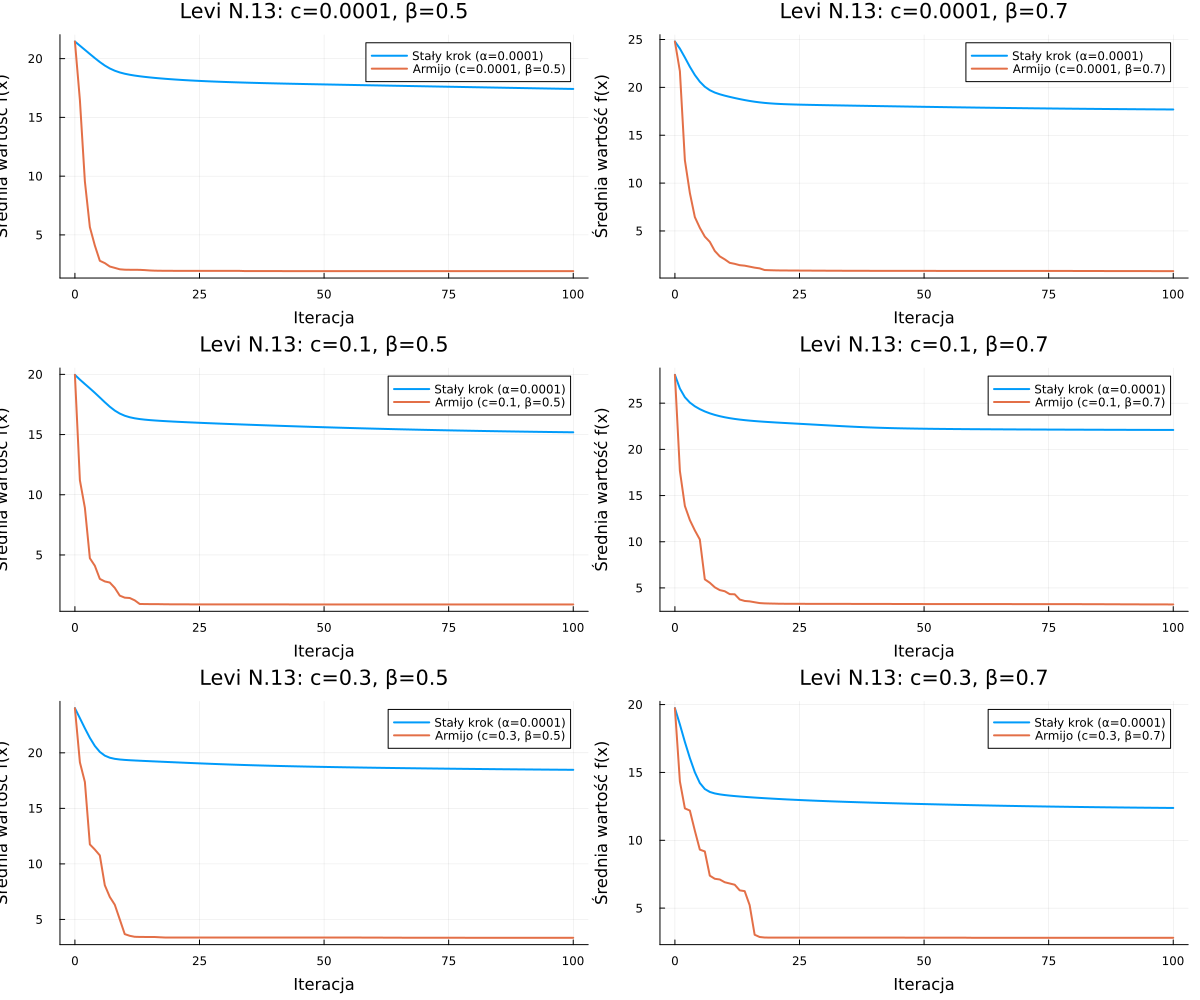

In [21]:
# Porównanie dla funkcji Levi N.13

n_points_levi = 10
n_steps_levi = 100
α_const_levi = 0.0001  # stały krok dla levi_n13

plots_comparison_levi = []

for (c, β) in armijo_params
    hist_const, hist_armijo = compare_methods_averaged(
        levi_n13, levi_domain, n_points_levi, n_steps_levi, α_const_levi, c, β
    )
    
    p = plot(0:n_steps_levi, hist_const, 
             label="Stały krok (α=$α_const_levi)",
             xlabel="Iteracja", 
             ylabel="Średnia wartość f(x)",
             title="Levi N.13: c=$c, β=$β",
             linewidth=2,
             legend=:topright)
    plot!(p, 0:n_steps_levi, hist_armijo, 
          label="Armijo (c=$c, β=$β)",
          linewidth=2)
    
    push!(plots_comparison_levi, p)
end

plot(plots_comparison_levi..., layout=(3, 2), size=(1200, 1000))

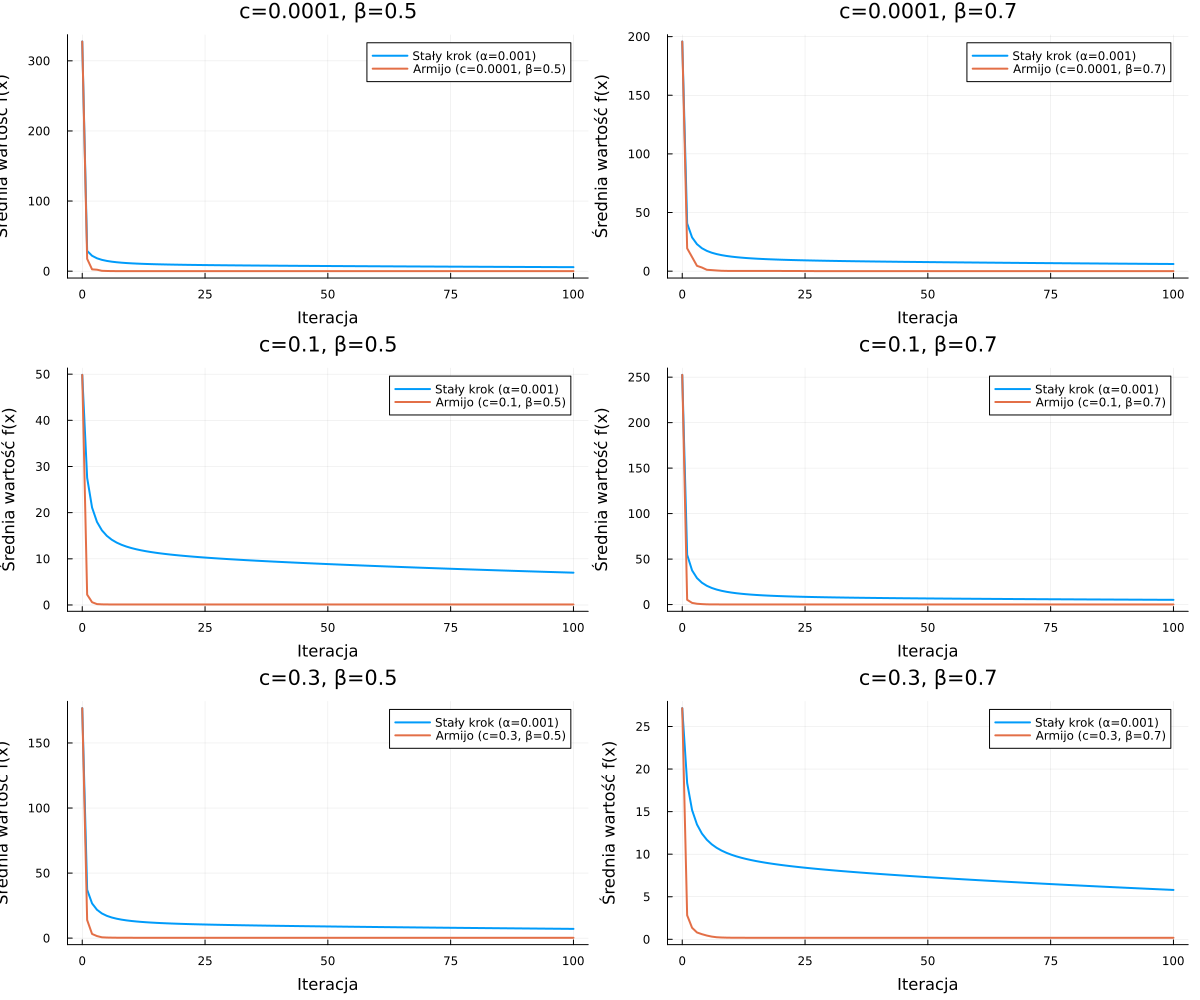

In [22]:
# Porównanie dla funkcji Three Hump Camel

n_points = 10
n_steps = 100
α_const = 0.001  # stały krok dla three_hump_camel

plots_comparison = []

for (c, β) in armijo_params
    hist_const, hist_armijo = compare_methods_averaged(
        three_hump_camel, three_hump_domain, n_points, n_steps, α_const, c, β
    )
    
    p = plot(0:n_steps, hist_const, 
             label="Stały krok (α=$α_const)",
             xlabel="Iteracja", 
             ylabel="Średnia wartość f(x)",
             title="c=$c, β=$β",
             linewidth=2,
             legend=:topright)
    plot!(p, 0:n_steps, hist_armijo, 
          label="Armijo (c=$c, β=$β)",
          linewidth=2)
    
    push!(plots_comparison, p)
end

plot(plots_comparison..., layout=(3, 2), size=(1200, 1000))

In [23]:
# Parametry do testowania (c, β)
armijo_params = [
    (0.0001, 0.5),
    (0.0001, 0.7),
    (0.1, 0.5),
    (0.1, 0.7),
    (0.3, 0.5),
    (0.3, 0.7)
]

6-element Vector{Tuple{Float64, Float64}}:
 (0.0001, 0.5)
 (0.0001, 0.7)
 (0.1, 0.5)
 (0.1, 0.7)
 (0.3, 0.5)
 (0.3, 0.7)